# <center>MDSA D212 Data Mining II</center> 

## <center>Task 2  Dimension Reduction Methods</center>

## <center>Rev. 2</center>

## <center>Justin Jordan</center>

## <center>6/23/2026</center>

## <center>WGU</center>



### Scenario 1
One of the most critical factors in customer relationship management that directly affects a company’s long-term profitability is understanding the customers. When a company understands its customers’ characteristics, it is better able to target products and marketing campaigns for customers, resulting in better profits for the company in the long term.



You are an analyst for a telecommunications company that wants to better understand the characteristics of its customers. You have been asked to use principal component analysis (PCA) to analyze customer data to identify the principal variables of your customers, ultimately enabling better business and strategic decision-making.

## Part I: Research Question

### A.  Describe the purpose of this data mining by doing the following:

1.  Propose one question relevant to a real-world organizational situation that you will answer by using PCA.

    - Can we reduce the dimensionality of the Churn dataset using PCA?       

2.  Define one goal of the data analysis. Ensure that your goal is reasonable within the scope of the scenario and is represented in the available data.
    - The goal of this analysis is to reduce dimensionality to identify principal components within the data set and determine the optimal number of variables that can be used for future analysis.       

## Part II: Method Justification

### B.   Explain the reasons for using PCA by doing the following::

1.  Explain how PCA analyzes the selected data set. Include expected outcomes.
    -   PCA (Principal Component Analysis) is a statistical technique aimed at reducing high-dimensional datasets to lower dimensions while preserving the maximum variance in the data. By doing so, it makes the underlying structure of the dataset more understandable and manageable(Guler, 2025).

        This statistical technique involves both linear algebra and matrix operations, and it transforms the original dataset into a new coordinate system that is structured by the principal components. The eigenvectors and eigenvalues from the covariance matrix that underpin the principal components allow for the analysis of these linear transformations.  Eigenvectors provide the direction of variance in the scatterplot. Eigenvalues are the coefficients of the eigenvectors; these denote the importance of this directional data. Therefore, a high eigenvalue means that the corresponding eigenvector is more critical. Since principal components represent the directions of maximum variance in the data, they are also the eigenvectors of the covariance matrix(What is Principal Component Analysis (PCA)? | IBM).  The expected outcome is to reduce dimensionality with a simplified data set that will provide explained variance within each PCA.

        PCA Steps are as follows:
        1. Standard ize the range of initial continuous variables
        2. Compute the covariance matrix to identify correlations
        3. Compute the eigenvectors and eigenvalues of the covariance matrix
        4. Select Principal components
        5. Transform data into new coordiante system    

2.  Summarize one assumption of PCA.
    - One assumption of PCA is it is sensitive to scaling.  Variables with larger numerical ranges will disproportionately dominate the pricipal components, making standardization a necessary step.  Another assumption is that all variables used must be correlated.  If any are independent, PCA will not be able to find meaningful components.       

       
        

## Part III: Data Preparation

### C.  Perform data preparation for the chosen data set by doing the following:

1.  Identify the continuous data set variables that you will need to answer the PCA question proposed in part A1.
    - Lat
    - Lng
    - Income
    - Outage_sec_perweek
    - Tenure
    - MonthlyCharge
    - Bandwidth_GB_Year


2.   Standardize the continuous data set variables identified in part C1. Include a copy of the cleaned data set.

- Code for C2 is below.  Code includes loading of libraries, load of initial dataset, dataset cleaning and standardization of variables listed above. 

In [1]:
# code for c3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# code for data frame
churn = pd.read_csv("C:/users/jjord/Documents/WGU/D212/d212_pa2/churn_clean.csv")

# Profile of Data Frame
churn.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [2]:
# Missing values using isnull
churn.isnull().sum()

CaseOrder                  0
Customer_id                0
Interaction                0
UID                        0
City                       0
State                      0
County                     0
Zip                        0
Lat                        0
Lng                        0
Population                 0
Area                       0
TimeZone                   0
Job                        0
Children                   0
Age                        0
Income                     0
Marital                    0
Gender                     0
Churn                      0
Outage_sec_perweek         0
Email                      0
Contacts                   0
Yearly_equip_failure       0
Techie                     0
Contract                   0
Port_modem                 0
Tablet                     0
InternetService         2129
Phone                      0
Multiple                   0
OnlineSecurity             0
OnlineBackup               0
DeviceProtection           0
TechSupport   

In [3]:
# look at unique values for InternetService
churn.InternetService.unique()

array(['Fiber Optic', 'DSL', nan], dtype=object)

In [4]:
# Impute nulls for InternetService
churn["InternetService"].fillna("No Internet Service", inplace=True)

In [5]:
# verify InternetService no longer has nulls
churn["InternetService"].isnull().sum()

0

In [6]:
# rename item columns
churn.rename(
    columns={
        "Item1": "Timely_response",
        "Item2": "Timely_fixes",
        "Item3": "Timely_replacements",
        "Item4": "Reliability",
        "Item5": "Options",
        "Item6": "Respectful_response",
        "Item7": "Courteous_exchange",
        "Item8": "Active_listening",
    },
    inplace=True,
)

In [7]:
#profile df after clean
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [8]:
# code for outliers.
churn.describe()

,CaseOrder,Zip,Lat,Lng,Population,Children,Age,Income,Outage_sec_perweek,Email,...,MonthlyCharge,Bandwidth_GB_Year,Timely_response,Timely_fixes,Timely_replacements,Reliability,Options,Respectful_response,Courteous_exchange,Active_listening
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,49153.319600,38.757567,-90.782536,9756.562400,2.0877,53.078400,39806.926771,10.001848,12.016000,...,172.624816,3392.341550,3.490800,3.505100,3.487000,3.497500,3.492900,3.497300,3.509500,3.495600
std,2886.89568,27532.196108,5.437389,15.156142,14432.698671,2.1472,20.698882,28199.916702,2.976019,3.025898,...,42.943094,2185.294852,1.037797,1.034641,1.027977,1.025816,1.024819,1.033586,1.028502,1.028633
min,1.00000,601.000000,17.966120,-171.688150,0.000000,0.0000,18.000000,348.670000,0.099747,1.000000,...,79.978860,155.506715,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,26292.500000,35.341828,-97.082812,738.000000,0.0000,35.000000,19224.717500,8.018214,10.000000,...,139.979239,1236.470827,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,5000.50000,48869.500000,39.395800,-87.918800,2910.500000,1.0000,53.000000,33170.605000,10.018560,12.000000,...,167.484700,3279.536903,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000
75%,7500.25000,71866.500000,42.106908,-80.088745,13168.000000,3.0000,71.000000,53246.170000,11.969485,14.000000,...,200.734725,5586.141370,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,10000.00000,99929.000000,70.640660,-65.667850,111850.000000,10.0000,89.000000,258900.700000,21.207230,23.000000,...,290.160419,7158.981530,7.000000,7.000000,8.000000,7.000000,7.000000,8.000000,7.000000,8.000000


In [9]:
# dataframe for variables

prep_churn = churn[["Lat","Lng","Income","Outage_sec_perweek","Tenure","MonthlyCharge","Bandwidth_GB_Year"]]



In [10]:
# profile df
prep_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Lat                 10000 non-null  float64
 1   Lng                 10000 non-null  float64
 2   Income              10000 non-null  float64
 3   Outage_sec_perweek  10000 non-null  float64
 4   Tenure              10000 non-null  float64
 5   MonthlyCharge       10000 non-null  float64
 6   Bandwidth_GB_Year   10000 non-null  float64
dtypes: float64(7)
memory usage: 547.0 KB


In [11]:
prep_churn.describe()

,Lat,Lng,Income,Outage_sec_perweek,Tenure,MonthlyCharge,Bandwidth_GB_Year
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,38.757567,-90.782536,39806.926771,10.001848,34.526188,172.624816,3392.341550
std,5.437389,15.156142,28199.916702,2.976019,26.443063,42.943094,2185.294852
min,17.966120,-171.688150,348.670000,0.099747,1.000259,79.978860,155.506715
25%,35.341828,-97.082812,19224.717500,8.018214,7.917694,139.979239,1236.470827
50%,39.395800,-87.918800,33170.605000,10.018560,35.430507,167.484700,3279.536903
75%,42.106908,-80.088745,53246.170000,11.969485,61.479795,200.734725,5586.141370
max,70.640660,-65.667850,258900.700000,21.207230,71.999280,290.160419,7158.981530


In [12]:
#scale data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(prep_churn)
scaled_data = pd.DataFrame(scaler.fit_transform(prep_churn), columns= prep_churn.columns)

scaled_data.head()

,Lat,Lng,Income,Outage_sec_perweek,Tenure,MonthlyCharge,Bandwidth_GB_Year
0,3.217410,-2.810432,-0.398778,-0.679978,-1.048746,-0.003943,-1.138487
1,1.024691,0.431644,-0.641954,0.570331,-1.262001,1.630326,-1.185876
2,1.213570,-2.142079,-1.070885,0.252347,-0.709940,-0.295225,-0.612138
3,-1.065031,-1.746273,-0.740525,1.650506,-0.659524,-1.226521,-0.561857
4,-1.724710,-0.331512,0.009478,-0.623156,-1.242551,-0.528086,-1.428184


In [13]:
#export standardized data set
scaled_data.to_csv('prep_churn.csv', index=False)

## Part IV: Analysis

### D.  Perform PCA by doing the following:
1.  Determine the matrix of all the principal components.

    Below is the code used to generate the matrix.  The first PCA will contain as many PCs as we have variables(7).  The rows are titled as the column they represent indicate how much each variable contributes to the PC.  We can see in PCA1, Tenure and Bandwidth_GB_Year are heavily influenced while the rest have little influence in comparison in PCA1.     


In [14]:
#d1 code
pca = PCA(n_components=prep_churn.shape[1], random_state=7)
pca.fit(scaled_data)
pca_print = pd.DataFrame(pca.transform(scaled_data), columns =['PCA1','PCA2','PCA3','PCA4','PCA5','PCA6','PCA7'])
load = pd.DataFrame(pca.components_.T, columns = ['PCA1','PCA2','PCA3','PCA4','PCA5','PCA6','PCA7'], index = scaled_data.columns)
load

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7
Lat,-0.023929,0.699473,-0.122083,0.024641,-0.034349,-0.702476,0.001028
Lng,0.007948,-0.706476,0.003629,0.072063,0.030741,-0.703332,0.000755
Income,0.003751,0.072029,0.330376,0.904620,0.257294,0.033327,-0.001254
Outage_sec_perweek,0.005784,-0.026424,-0.687545,0.045709,0.721765,0.059290,0.000025
Tenure,0.705612,0.020180,0.038144,-0.028709,0.034436,-0.014295,-0.705716
MonthlyCharge,0.040770,-0.071391,-0.633843,0.415871,-0.639926,0.083492,-0.045372
Bandwidth_GB_Year,0.706941,0.015428,-0.001818,-0.000478,-0.006245,-0.007080,0.707038


### D.  Perform PCA by doing the following:(continued)

 D2.  Identify the total number of principal components, using the elbow rule or the Kaiser criterion. Include a screenshot of the scree plot.

       code for d2 is below as well as scree plot

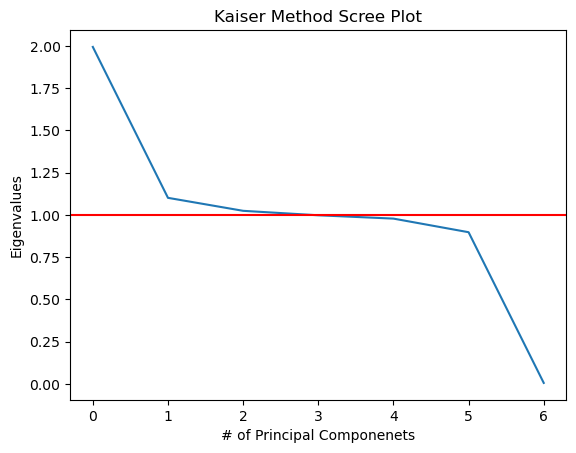

In [15]:
#d2 code

cov_matrix = np.dot(scaled_data.T, scaled_data)/prep_churn.shape[0]
eigenvalues = [np.dot(eigenvector.T, np.dot(cov_matrix,eigenvector)) for eigenvector in pca.components_]
plt.plot(eigenvalues)
plt.xlabel('# of Principal Componenets')
plt.ylabel('Eigenvalues')
plt.title('Kaiser Method Scree Plot')
plt.axhline(y=1, color = 'red')
plt.show()



In [16]:
print(eigenvalues)

[1.993780404847027, 1.1011689552324273, 1.0243810874506434, 0.9979795925447017, 0.978373910317856, 0.8978607514858117, 0.006455298121533553]


### D2 continued

The red line on the scree plot is the delineator between principal components to be kept and discarded.  According to the Kaiser Rule, principal components with an eigenvalue greater than 1 will be kept, those below 1 will be discarded.  

Based on the Scree Plot above and using the Kaiser Method, it appears the optimal number could be either 3 or 4, as the plot flattens but does go below 1 around the 4th principal component.  Once I printed the values, it does show 4 as being below 1.  

For this reason we are going to choose 3 as the optimal number.  

### D3.  Identify the variance of each of the principal components identified in part D2.

Variance for each Principal Component from D2:

    PC1 0.28482577 or 28% of the variance(rounded)
    PC2 0.15730985 or 16% of the variance(rounded)
    PC3 0.14634016 or 15% of the variance(rounded)
   

Below is code for the variance of the original 7 variables as well as the 3 variables chosen from D2.  Variance is the same for the first 3 in each.  

In [17]:
#d3 code
# variance for all 7 variables 
print(pca.explained_variance_ratio_)

[0.28482577 0.15730985 0.14634016 0.14256851 0.1397677  0.12826582
 0.00092219]


In [18]:
#d3 code cont.
#set number of principal components(3) from d2
pca_final = PCA(n_components=3, random_state= 7)
pca_final.fit(scaled_data)
pca_final_print = pd.DataFrame(pca_final.transform(scaled_data), columns= ['PCA1', 'PCA2', 'PCA3'])
print(pca_final.explained_variance_ratio_)

[0.28482577 0.15730985 0.14634016]


### D4.  Identify the total variance captured by the principal components identified in part D2.

The total variance for the 3 principal components is 0.5884757782185854 or 59%(rounded).



In [19]:
#d4 code
total_variance = pca.explained_variance_ratio_[:3].sum()
print(total_variance)

0.5884757782185854


### D5.  Summarize the results of your data analysis.

Dimensionality of the data set was reduced by performing PCA on the 7 selected continuous variables from the dataset resulting in an optimal number of principal components of three.  The optimal number of components was determined by a Scree Plot and the Kaiser Method for Explained Variance.  However, when we calculated the total variance on the 3 principal components it is only 0.5884757782185854 or roughly 59%.  

As it is usually up to the analyst performing the analysis to decide if the amount of explained variance is acceptable or not.  59% of explained variance is a moderate amount and very middle of the road.  It may be beneficial to re-run the PCA with a different set of continuous variables to see if the explained variance could be higher but we were ultimately able to answer the question posed in A1.  

    

## Part V: Attachments

### E.  Record the web sources used to acquire data or segments of third-party code to support the application. Ensure the web sources are reliable.
    None used.

### F.  Acknowledge sources, using in-text citations and references, for content that is quoted, paraphrased, or summarized.
    WGU. (n.d.). Churn Data Consideration and Dictionary. Data Files and Associated Dictionary Files. https://access.wgu.edu/ASP3/aap/content/d9rkejv84kd9rk30fi2l.zip

    Guler, E. (2025, October 15). Principal Component Analysis (PCA): A Complete Guide for Data Scientists. https://medium.com/@enesgulerdev/understanding-principal-component-analysis-pca-b1d8f5aaf766 

    What is Principal Component Analysis (PCA)? | IBM. (n.d.). https://www.ibm.com/think/topics/principal-component-analysis 

    